In [1]:
import pandas as pd
import sqlite3

In [2]:
try:
  connect = sqlite3.connect('data/checking-logs.sqlite')
  print('OK. Connected to sqlite')

except sqlite3.Error as error:
  print('Error with connection:', error)

OK. Connected to sqlite


In [5]:
query = '''
SELECT *
FROM checker
WHERE uid LIKE 'user_%'
'''
checker = pd.io.sql.read_sql(query, connect, parse_dates=['datetime'])
checker['timestamp'] = checker['timestamp'].astype('datetime64[us]')
checker

,index,status,success,timestamp,numTrials,labname,uid
0,7,ready,0,2020-04-17 05:19:02.744528,1,project1,user_4
1,8,checking,0,2020-04-17 05:22:35.249331,2,project1,user_4
2,9,ready,1,2020-04-17 05:22:45.549397,2,project1,user_4
3,10,checking,1,2020-04-17 05:34:14.691200,3,project1,user_4
4,11,ready,1,2020-04-17 05:34:24.422370,3,project1,user_4
...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
3203,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
3204,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
3205,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [10]:
##night is from 0:00:00 to 03:59:59, morning is from 04:00:00 to 09:59:59, afternoon
##is from 10:00:00 to 16:59:59, evening is from 17:00:00 to 23:59:59

In [11]:
checker['hh.mm'] = checker['timestamp'].dt.strftime('%H.%M')
checker['hh.mm'] = checker['hh.mm'].astype('float')
checker['timestamp'] = checker['timestamp'].dt.date
checker

,index,status,success,timestamp,numTrials,labname,uid,hh.mm,daytime
0,7,ready,0,2020-04-17,1,project1,user_4,5.19,morning
1,8,checking,0,2020-04-17,2,project1,user_4,5.22,morning
2,9,ready,1,2020-04-17,2,project1,user_4,5.22,morning
3,10,checking,1,2020-04-17,3,project1,user_4,5.34,morning
4,11,ready,1,2020-04-17,3,project1,user_4,5.34,morning
...,...,...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21,7,laba06s,user_1,20.19,evening
3203,3398,checking,0,2020-05-21,8,laba06s,user_1,20.22,evening
3204,3399,ready,0,2020-05-21,8,laba06s,user_1,20.22,evening
3205,3400,checking,0,2020-05-21,9,laba06s,user_1,20.37,evening


In [12]:
bins = [0, 3.59, 9.59, 16.59, 23.59]
labels = ['night','morning','afternoon','evening']
checker['daytime']=pd.cut(checker['hh.mm'],bins = bins,labels = labels)
checker

,index,status,success,timestamp,numTrials,labname,uid,hh.mm,daytime
0,7,ready,0,2020-04-17,1,project1,user_4,5.19,morning
1,8,checking,0,2020-04-17,2,project1,user_4,5.22,morning
2,9,ready,1,2020-04-17,2,project1,user_4,5.22,morning
3,10,checking,1,2020-04-17,3,project1,user_4,5.34,morning
4,11,ready,1,2020-04-17,3,project1,user_4,5.34,morning
...,...,...,...,...,...,...,...,...,...
3202,3397,ready,0,2020-05-21,7,laba06s,user_1,20.19,evening
3203,3398,checking,0,2020-05-21,8,laba06s,user_1,20.22,evening
3204,3399,ready,0,2020-05-21,8,laba06s,user_1,20.22,evening
3205,3400,checking,0,2020-05-21,9,laba06s,user_1,20.37,evening


In [53]:
df = checker[['timestamp', 'daytime']].groupby('timestamp').value_counts().unstack(1)
df

daytime,night,morning,afternoon,evening
timestamp,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25
2020-04-22,0,0,4,24
2020-04-23,2,6,15,20
2020-04-24,0,0,4,12
2020-04-25,1,21,33,49


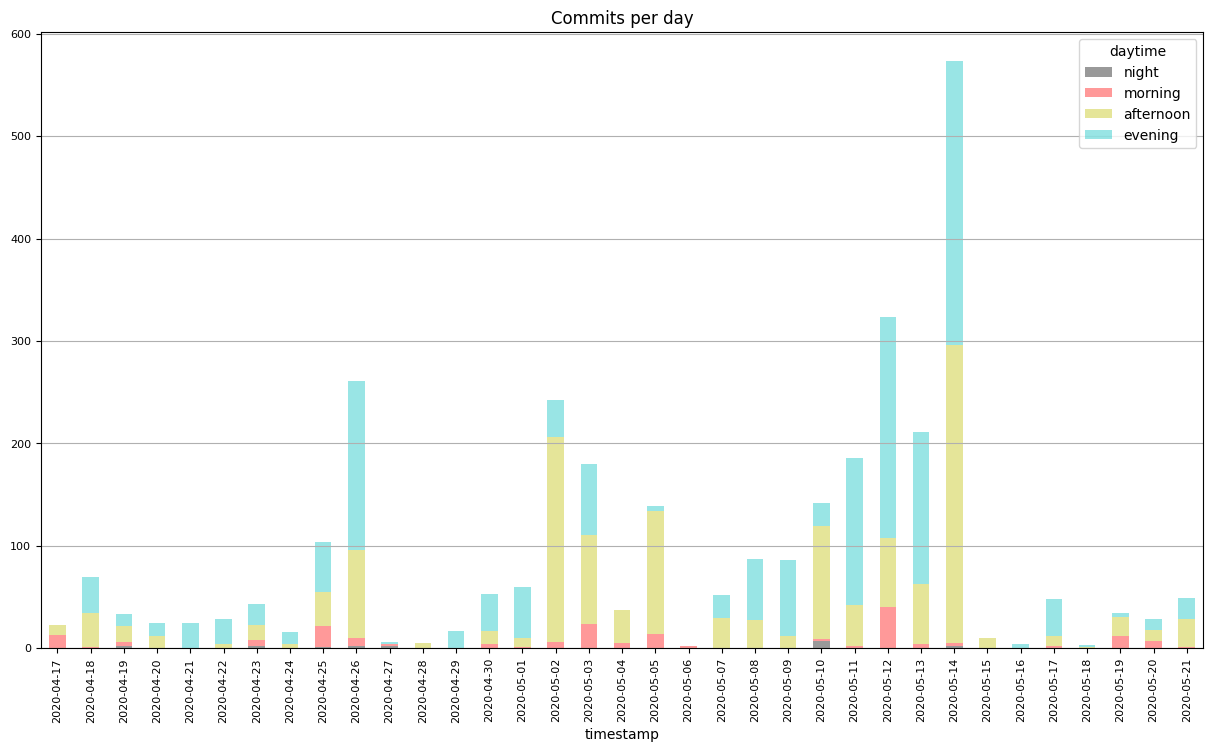

In [87]:
plt = df.plot.bar(figsize=(15,8),
    fontsize=8,
    title='Commits per day',
    rot=90,
    alpha=0.4,
    stacked=True,
    color=('black','red','y','c'))
plt.grid(axis='y')

In [ ]:
'''
 “When do our users usually commit the labs: in the night, morning, afternoon,
  or evening?”, the answer is the two most common periods.
Answer : afternon and morning
  '''

'\n “When do our users usually commit the labs: in the night, morning, afternoon,\n  or evening?”, the answer is the two most common periods.\nAnswer : afternon and morning\n  '

In [ ]:
 '''Which day has:
    * the most number of commits

answer: 2020.05.14
'''

In [ ]:
'''
* and at the same time, the number
 of commits in the evening is higher than in the afternoon?

 Answer:2020.05.14
'''

In [5]:
connect.close()